# Data Segmentation

This notebook defines the functions for data segmentation technique and it provides the compressed folder containing the segmented images of the ExampleFoodImageDataset, preserving the original dataset's classe folder structure.

The goal of this process is to reduce background noise and enhance the focus on the main objects within each image. In order to achieve this, we apply a threshold technique to isolate the foreground.

## Import libraries

In [6]:
import cv2
from google.colab.patches import cv2_imshow
import numpy as np
import os
from shutil import copyfile
import zipfile

## Functions

The function 'segmented_image' takes an image path as input and returns the final segmented image.

The second function processes all readable image files in an input directory, applies a segmentation process to each image using the first function and saves the resulting segmented images to an output directory, preserving the original filenames.

In [36]:
def segmented_image(image_path):
  img = cv2.imread(image_path)
  gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  blur = cv2.GaussianBlur(gray, (5,5), 0)
  _, thresh = cv2.threshold(blur,0,255,cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)
  thresh = cv2.bitwise_not(thresh)
  final_image = cv2.bitwise_and(img, img, mask=thresh)
  return final_image


In [29]:
def segmentation(input, output):
  if not os.path.exists(output):
    os.makedirs(output)

  for filename in os.listdir(input):
    image_path = os.path.join(input, filename)
    img = cv2.imread(image_path)
    if img is None:
      print(f"Warning: Could not read image {image_path}. Skipping.")
      continue
    final_image = segmented_image(image_path)
    output_path = os.path.join(output, filename)
    cv2.imwrite(output_path, final_image)

## Example of segmented image

In [3]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [7]:
copyfile('/content/gdrive/MyDrive/ExampleFoodImageDataset.zip', 'ExampleFoodImageDataset.zip')
zip = zipfile.ZipFile('ExampleFoodImageDataset.zip')
zip.extractall()
zip.close()

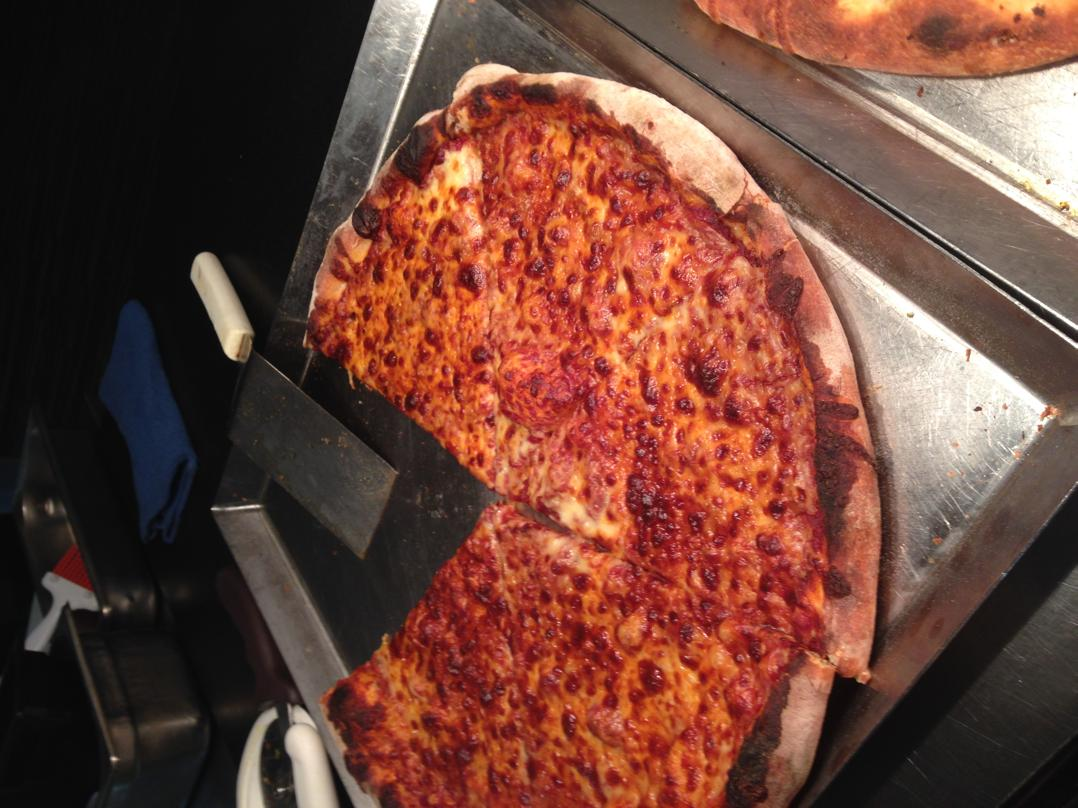

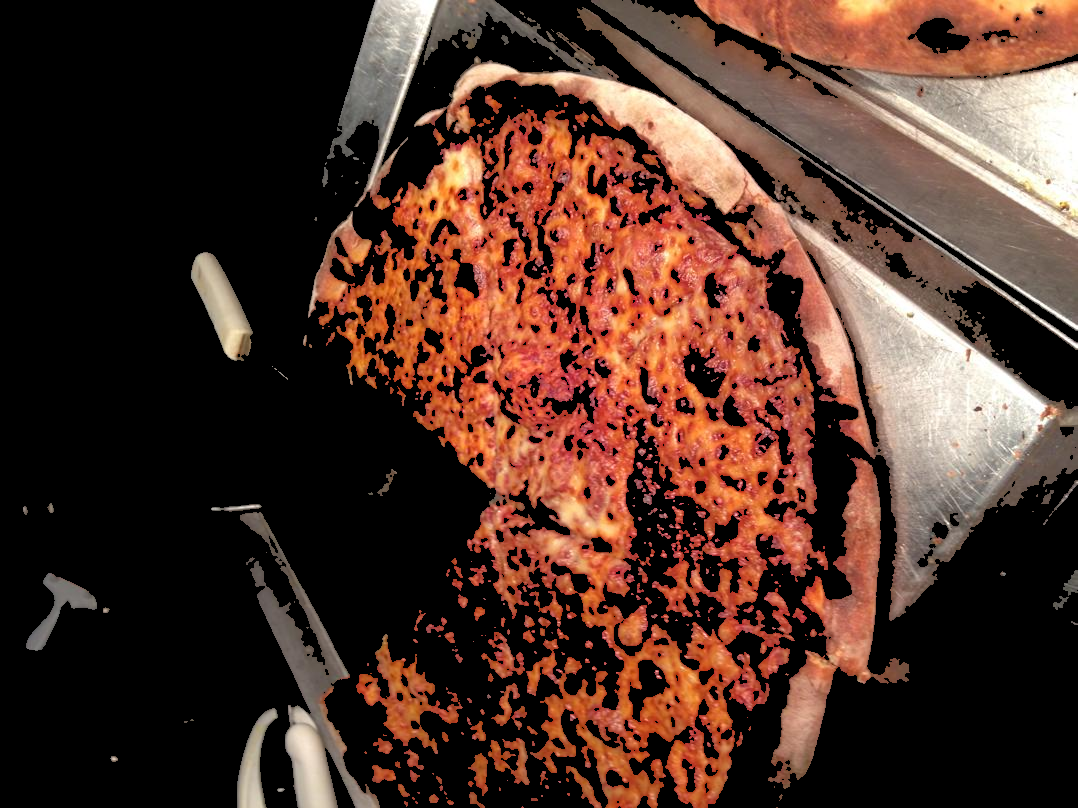

In [18]:
image_path = '/content/ExampleFoodImageDataset/pizza/pizza_437.jpg'
final_image = segmented_image(image_path)
cv2_imshow(cv2.imread(image_path))
cv2_imshow(final_image)

## Segmentation of the images from the dataset

Let's transform the dataset into a new version containing segmented images. We will process the images separately for each class to ensure the original folder structure is preserved.

In [19]:
segmentation('/content/ExampleFoodImageDataset/pizza', '/content/gdrive/MyDrive/Models_DL_project/food_segmentation/pizza')

In [20]:
segmentation('/content/ExampleFoodImageDataset/sushi', '/content/gdrive/MyDrive/Models_DL_project/food_segmentation/sushi')

In [21]:
segmentation('/content/ExampleFoodImageDataset/sashimi', '/content/gdrive/MyDrive/Models_DL_project/food_segmentation/sashimi')

In [22]:
segmentation('/content/ExampleFoodImageDataset/hot_dog', '/content/gdrive/MyDrive/Models_DL_project/food_segmentation/hot_dog')

In [23]:
segmentation('/content/ExampleFoodImageDataset/hamburger', '/content/gdrive/MyDrive/Models_DL_project/food_segmentation/hamburger')

In [24]:
segmentation('/content/ExampleFoodImageDataset/french_fries', '/content/gdrive/MyDrive/Models_DL_project/food_segmentation/french_fries')

In [25]:
segmentation('/content/ExampleFoodImageDataset/greek_salad', '/content/gdrive/MyDrive/Models_DL_project/food_segmentation/greek_salad')

In [30]:
segmentation('/content/ExampleFoodImageDataset/caesar_salad', '/content/gdrive/MyDrive/Models_DL_project/food_segmentation/caesar_salad')

In [31]:
segmentation('/content/ExampleFoodImageDataset/caprese_salad', '/content/gdrive/MyDrive/Models_DL_project/food_segmentation/caprese_salad')

### Creation of the zip file on the drive

In [35]:
def create_zip_file(folder_path, zip_file_path):
    with zipfile.ZipFile(zip_file_path, 'w') as zipf:
        for root, dirs, files in os.walk(folder_path):
            for file in files:
                file_path = os.path.join(root, file)
                arcname = os.path.relpath(file_path, folder_path)
                zipf.write(file_path, arcname)

folder_path = '/content/gdrive/MyDrive/Models_DL_project/food_segmentation'
zip_file_path = '/content/gdrive/MyDrive/Models_DL_project/food_segmentation.zip'
create_zip_file(folder_path, zip_file_path)